In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import folium

In [2]:
euclidean_matrix = pd.read_csv(f'Output\\euclidean_distance_matrix (Einme).csv') 
road_matrix = pd.read_csv(f'Output\\road_distance_matrix (Einme).csv')
locations = pd.read_csv(f'Input\\Sample data - Einme.csv')
print(f"Shape of euclidean_matrix: {euclidean_matrix.shape}")
print(f"Shape of road_matrix: {road_matrix.shape}") 
print(f"Shape of locations: {locations.shape}")

Shape of euclidean_matrix: (525, 526)
Shape of road_matrix: (525, 526)
Shape of locations: (525, 4)


In [3]:
display(euclidean_matrix.head())
display(road_matrix.head())

,Unnamed: 0,Main Office,161015,471918,471920,471924,471925,471947,471950,471953,...,475069,475070,475071,475072,475073,494379,494380,494381,494382,494383
0,Main Office,0.000000,19.166339,21.549503,40.957006,41.044154,18.643032,24.941986,22.210375,23.317105,...,8.864221,10.848136,13.874922,14.147847,12.897325,0.354006,2.200265,1.523099,0.676402,1.191719
1,161015,19.166339,0.000000,11.123316,21.982425,22.205567,18.599643,10.225391,5.668076,7.206730,...,14.551747,12.437748,10.497542,9.116081,10.759627,19.370673,17.092699,17.833686,18.739558,18.142582
2,471918,21.549503,11.123316,0.000000,23.304332,22.881057,10.094104,4.902964,6.764249,6.108733,...,13.216762,10.836443,7.684167,7.516024,8.660250,21.575947,19.408225,20.028913,20.911438,20.358035
3,471920,40.957006,21.982425,23.304332,0.000000,1.322019,33.252746,18.407746,19.144403,18.458556,...,34.698555,32.207068,29.181302,28.181866,29.953999,41.129236,38.811593,39.548002,40.474525,39.870718
4,471924,41.044154,22.205567,22.881057,1.322019,0.000000,32.742935,18.008977,19.058255,18.277006,...,34.569385,32.066556,28.996405,28.042058,29.794961,41.206363,38.883772,39.616961,40.546578,39.942458


,Unnamed: 0,Main Office,Client-161015,Client-471918,Client-471920,Client-471924,Client-471925,Client-471947,Client-471950,Client-471953,...,Client-475069,Client-475070,Client-475071,Client-475072,Client-475073,Client-494379,Client-494380,Client-494381,Client-494382,Client-494383
0,Main Office,0.0000,22.3228,39.8130,77.4797,66.6241,58.4860,35.9593,29.6500,31.0925,...,12.6002,15.6040,22.0283,20.1530,23.1774,0.4245,2.2683,1.7610,0.8425,1.2358
1,Client-161015,22.3228,0.0000,17.4902,55.1569,44.3013,31.1773,13.6365,7.3272,8.7697,...,21.5670,17.9966,14.4013,14.6966,15.5504,22.6093,24.5911,24.0838,23.1653,23.5586
2,Client-471918,39.8130,17.4902,0.0000,44.2246,33.3690,13.6871,7.1091,11.3709,9.1281,...,39.0572,35.4868,31.8915,32.1868,33.0406,40.0995,42.0813,41.5740,40.6555,41.0488
3,Client-471920,77.4797,55.1569,44.2246,0.0000,11.5512,57.9117,44.7758,49.0375,46.7948,...,76.7239,73.1535,69.5582,69.8535,70.7073,77.7662,79.7480,79.2407,78.3222,78.7155
4,Client-471924,66.6241,44.3013,33.3690,11.5512,0.0000,47.0561,33.9202,38.1819,35.9392,...,65.8683,62.2979,58.7026,58.9979,59.8517,66.9105,68.8924,68.3851,67.4666,67.8599


In [4]:
locations.head()

,Name,Latitude,Longitude,Type
0,Main Office,16.900944,95.178472,Office
1,161015,16.736735,95.123730,Client
2,471953,16.691339,95.172028,Client
3,471950,16.701789,95.162478,Client
4,471970,16.769770,95.228920,Client


In [5]:
road_matrix.columns

Index(['Unnamed: 0', 'Main Office', 'Client-161015', 'Client-471918',
       'Client-471920', 'Client-471924', 'Client-471925', 'Client-471947',
       'Client-471950', 'Client-471953',
       ...
       'Client-475069', 'Client-475070', 'Client-475071', 'Client-475072',
       'Client-475073', 'Client-494379', 'Client-494380', 'Client-494381',
       'Client-494382', 'Client-494383'],
      dtype='str', length=526)

In [6]:
road_matrix = road_matrix.rename(columns={'Unnamed: 0': 'Location'})

In [7]:
road_matrix['Location'] = road_matrix['Location'].str.replace('Client-', '').str.replace('Main Office', '0').astype(int)
road_matrix.head()

# Set 'Location' as index
road_matrix.set_index('Location', inplace=True)
road_matrix.head()

,Main Office,Client-161015,Client-471918,Client-471920,Client-471924,Client-471925,Client-471947,Client-471950,Client-471953,Client-471954,...,Client-475069,Client-475070,Client-475071,Client-475072,Client-475073,Client-494379,Client-494380,Client-494381,Client-494382,Client-494383
Location,,,,,,,,,,,,,,,,,,,,,
0,0.0000,22.3228,39.8130,77.4797,66.6241,58.4860,35.9593,29.6500,31.0925,29.7795,...,12.6002,15.6040,22.0283,20.1530,23.1774,0.4245,2.2683,1.7610,0.8425,1.2358
161015,22.3228,0.0000,17.4902,55.1569,44.3013,31.1773,13.6365,7.3272,8.7697,7.4567,...,21.5670,17.9966,14.4013,14.6966,15.5504,22.6093,24.5911,24.0838,23.1653,23.5586
471918,39.8130,17.4902,0.0000,44.2246,33.3690,13.6871,7.1091,11.3709,9.1281,11.9074,...,39.0572,35.4868,31.8915,32.1868,33.0406,40.0995,42.0813,41.5740,40.6555,41.0488
471920,77.4797,55.1569,44.2246,0.0000,11.5512,57.9117,44.7758,49.0375,46.7948,49.5741,...,76.7239,73.1535,69.5582,69.8535,70.7073,77.7662,79.7480,79.2407,78.3222,78.7155
471924,66.6241,44.3013,33.3690,11.5512,0.0000,47.0561,33.9202,38.1819,35.9392,38.7185,...,65.8683,62.2979,58.7026,58.9979,59.8517,66.9105,68.8924,68.3851,67.4666,67.8599


In [8]:
road_matrix.columns

Index(['Main Office', 'Client-161015', 'Client-471918', 'Client-471920',
       'Client-471924', 'Client-471925', 'Client-471947', 'Client-471950',
       'Client-471953', 'Client-471954',
       ...
       'Client-475069', 'Client-475070', 'Client-475071', 'Client-475072',
       'Client-475073', 'Client-494379', 'Client-494380', 'Client-494381',
       'Client-494382', 'Client-494383'],
      dtype='str', length=525)

In [9]:
main_office_distances = road_matrix['Main Office'].iloc[1:] 
main_office_distances.head()

Location
161015    22.3228
471918    39.8130
471920    77.4797
471924    66.6241
471925    58.4860
Name: Main Office, dtype: float64

In [10]:
# get 20 furthest clients Ids 
top_20_furthest = main_office_distances.nlargest(20)
print(top_20_furthest)

Location
471973    123.5458
472020    123.2088
471972    120.1204
471971    120.0459
472432    117.8455
472433    115.0292
472276    112.7572
472431    112.7040
472093    112.3360
472274    108.8329
472157    106.5249
472158    106.4953
472159    105.1674
472154    102.5201
472156    102.1557
472313     92.9412
472107     89.7184
472211     84.2523
472081     78.2076
471920     77.4797
Name: Main Office, dtype: float64


In [11]:
print("Top 20 Furthest Clients from Main Office:")
for i, (client_name, distance) in enumerate(top_20_furthest.items(), 1):
    print(f"{i:2}. {client_name:<20} {distance:.2f} km")


Top 20 Furthest Clients from Main Office:
 1. 471973               123.55 km
 2. 472020               123.21 km
 3. 471972               120.12 km
 4. 471971               120.05 km
 5. 472432               117.85 km
 6. 472433               115.03 km
 7. 472276               112.76 km
 8. 472431               112.70 km
 9. 472093               112.34 km
10. 472274               108.83 km
11. 472157               106.52 km
12. 472158               106.50 km
13. 472159               105.17 km
14. 472154               102.52 km
15. 472156               102.16 km
16. 472313               92.94 km
17. 472107               89.72 km
18. 472211               84.25 km
19. 472081               78.21 km
20. 471920               77.48 km


In [12]:
locations.head()

,Name,Latitude,Longitude,Type
0,Main Office,16.900944,95.178472,Office
1,161015,16.736735,95.123730,Client
2,471953,16.691339,95.172028,Client
3,471950,16.701789,95.162478,Client
4,471970,16.769770,95.228920,Client


In [13]:
# Get Main Office coordinates
main_office = locations[locations['Name'] == 'Main Office'].iloc[0]
main_lat, main_lon = main_office['Latitude'], main_office['Longitude']

print(f"Main Office Coordinates: Latitude={main_lat}, Longitude={main_lon}")

Main Office Coordinates: Latitude=16.900944, Longitude=95.178472


In [14]:



# Create map centered on Main Office
m = folium.Map(location=[main_lat, main_lon], zoom_start=10, tiles='OpenStreetMap')

# Add Main Office marker (blue)
folium.Marker(
    location=[main_lat, main_lon],
    popup='Main Office',
    icon=folium.Icon(color='blue', icon='home', prefix='fa')
).add_to(m)

# Add markers for 20 furthest clients (red)
for i, (client_name, distance) in enumerate(top_20_furthest.items(), 1):
    # client_name is like "Client-471973", extract "471973"
    client_id = str(client_name).replace('Client-', '')
    
    # Match with Name column in sample_df
    client_row = locations[locations['Name'].astype(str) == client_id]
    print(f"Processing {client_name} (ID: {client_id}) - Distance: {distance:.2f} km")
    if not client_row.empty:
        lat = client_row.iloc[0]['Latitude']
        lon = client_row.iloc[0]['Longitude']
        print(f"Coordinates for {client_name}: Latitude={lat}, Longitude={lon}")
        folium.Marker(
            location=[lat, lon],
            popup=f"#{i}: {client_name}<br>Distance: {distance:.2f} km",
            icon=folium.Icon(color='red', icon='user', prefix='fa')
        ).add_to(m)
    else:
        print(f"Warning: No coordinates found for {client_name}")

# Save the map
m.save('Output\\furthest_clients_map.html')
print("\nMap saved to: furthest_clients_map.html")


Processing 471973 (ID: 471973) - Distance: 123.55 km
Coordinates for 471973: Latitude=16.535891, Longitude=95.253448
Processing 472020 (ID: 472020) - Distance: 123.21 km
Coordinates for 472020: Latitude=16.545549, Longitude=95.257957
Processing 471972 (ID: 471972) - Distance: 120.12 km
Coordinates for 471972: Latitude=16.529137, Longitude=95.266893
Processing 471971 (ID: 471971) - Distance: 120.05 km
Coordinates for 471971: Latitude=16.53031, Longitude=95.266579
Processing 472432 (ID: 472432) - Distance: 117.85 km
Coordinates for 472432: Latitude=16.539591, Longitude=95.28334
Processing 472433 (ID: 472433) - Distance: 115.03 km
Coordinates for 472433: Latitude=16.55135, Longitude=95.298019
Processing 472276 (ID: 472276) - Distance: 112.76 km
Coordinates for 472276: Latitude=16.566883, Longitude=95.306919
Processing 472431 (ID: 472431) - Distance: 112.70 km
Coordinates for 472431: Latitude=16.572611, Longitude=95.307701
Processing 472093 (ID: 472093) - Distance: 112.34 km
Coordinates fo

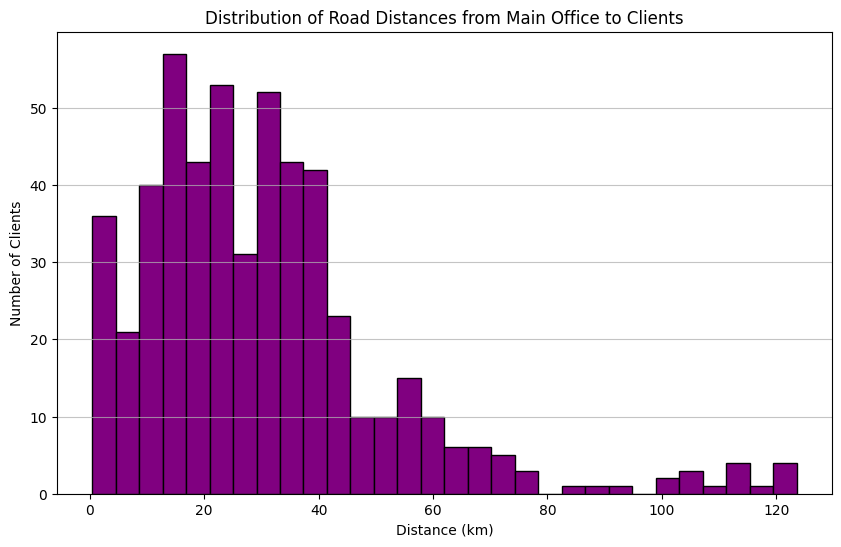

In [16]:
# show the distrubution of distances to the main office
plt.figure(figsize=(10, 6))
plt.hist(main_office_distances, bins=30, color='purple', edgecolor='black')
plt.title('Distribution of Road Distances from Main Office to Clients')
plt.xlabel('Distance (km)')
plt.ylabel('Number of Clients')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [25]:
# show stats about the distances
print("Distance Statistics from Main Office to Clients:")
print(f"Mean Distance: {main_office_distances.mean():.2f} km")
print(f"Median Distance: {main_office_distances.median():.2f} km")
print(f"Minimum Distance: {main_office_distances.min():.2f} km")
print(f"Maximum Distance: {main_office_distances.max():.2f} km")
print(f"Standard Deviation: {main_office_distances.std():.2f} km")

Distance Statistics from Main Office to Clients:
Mean Distance: 30.37 km
Median Distance: 27.13 km
Minimum Distance: 0.42 km
Maximum Distance: 123.55 km
Standard Deviation: 22.13 km


In [30]:
import statistics as stats
mean_val = stats.mean(main_office_distances)
stdev_val = stats.stdev(main_office_distances)
data_range = max(main_office_distances) - min(main_office_distances)
cv = stdev_val / mean_val
print(f"Mean: {mean_val:.2f}")
print(f"Median: {main_office_distances.median():.2f}")
print(f"Maximum: {main_office_distances.max():.2f}")
print(f"Minimum: {main_office_distances.min():.2f}")
print(f"Standard Deviation: {stdev_val:.2f}")
print(f"Range: {data_range}")
print(f"Coefficient of Variation: {cv:.2f}")
if stdev_val >= data_range * 0.8:
   print("High variability")
   print("Distances vary widely among clients, indicating some clients are much farther than others.")
else:
   print("Low variability")
   print("Distances are relatively consistent across clients.")

Mean: 30.37
Median: 27.13
Maximum: 123.55
Minimum: 0.42
Standard Deviation: 22.13
Range: 123.1213
Coefficient of Variation: 0.73
Low variability
Distances are relatively consistent across clients.
